In [6]:
from google.colab import files
uploaded = files.upload()

Saving inference.py to inference (1).py


In [7]:
from google.colab import files
uploaded = files.upload()

Saving lungvision_model.pth to lungvision_model.pth


In [8]:
from google.colab import files
uploaded = files.upload()

Saving gradcam.py to gradcam (1).py


In [9]:
from google.colab import files
uploaded = files.upload()


Saving Malignant case.jpg to Malignant case.jpg
Saving Bengin case.jpg to Bengin case.jpg
Saving Normal case.jpg to Normal case.jpg


In [10]:
!pip install torch torchvision pillow matplotlib seaborn -q

# 🫁 LungVision AI — Experiment Notebook

Exploring predictions, confidence scores, and Grad-CAM
visualizations from the trained lung cancer detection model.

> Model trained on Google Colab separately.
> Dataset: LC25000 Lung Cancer Histopathological Images


In [11]:
import sys
sys.path.append('.')  # so inference.py and gradcam.py are found

from inference import load_model

model = load_model("lungvision_model.pth")
print("✅ Model loaded successfully")

✅ Model loaded successfully


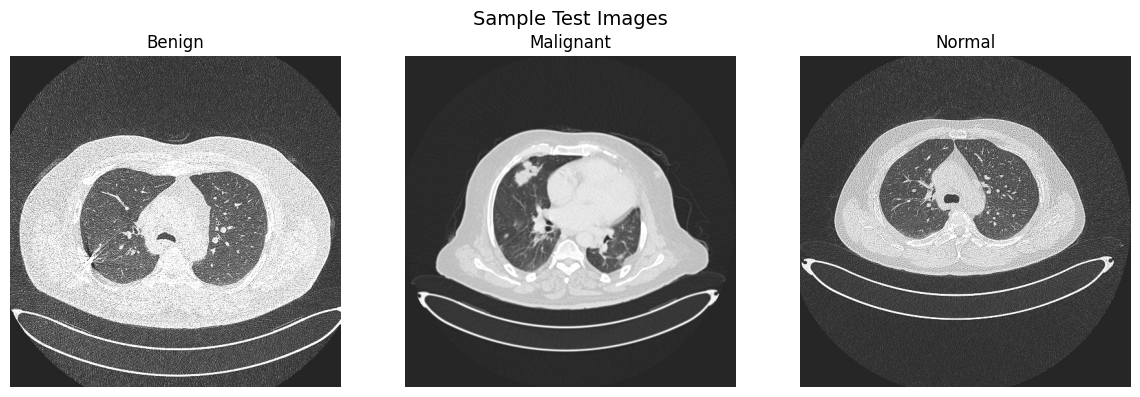

In [13]:
#Show test images

import matplotlib.pyplot as plt
from PIL import Image

# Change these to your actual uploaded image names
images = {
    "Benign": "Bengin case.jpg",
    "Malignant": "Malignant case.jpg",
    "Normal": "Normal case.jpg"
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Sample Test Images", fontsize=14)

for ax, (label, path) in zip(axes, images.items()):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [14]:
# Run prediction

from inference import predict

for label, path in images.items():
    result = predict(path, model)
    print(f"Image: {label}")
    print(f"  Predicted : {result['prediction']}")
    print(f"  Confidence: {result['confidence']}%")
    print(f"  All Scores: {result['all_scores']}")
    print()

Image: Benign
  Predicted : Normal
  Confidence: 82.44%
  All Scores: {'Benign': 17.5, 'Malignant': 0.06, 'Normal': 82.44}

Image: Malignant
  Predicted : Malignant
  Confidence: 99.99%
  All Scores: {'Benign': 0.01, 'Malignant': 99.99, 'Normal': 0.0}

Image: Normal
  Predicted : Normal
  Confidence: 100.0%
  All Scores: {'Benign': 0.0, 'Malignant': 0.0, 'Normal': 100.0}



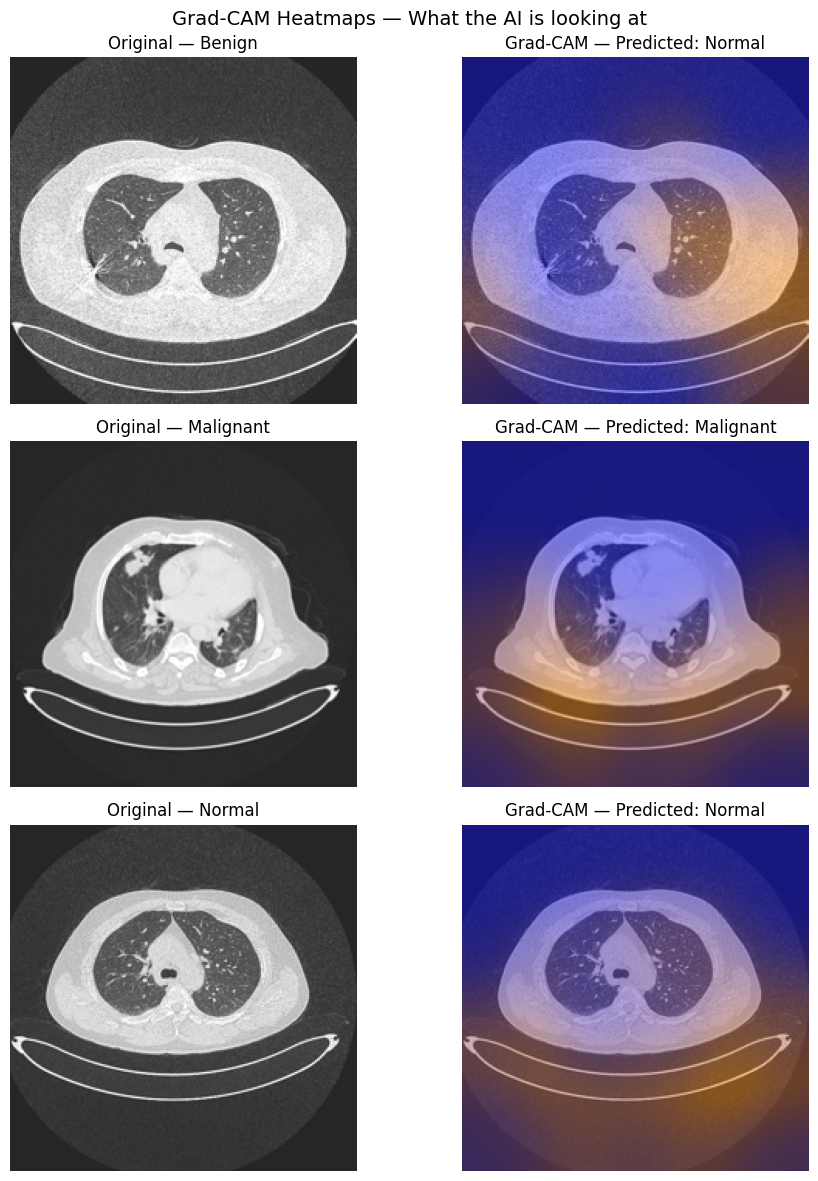

In [19]:
from gradcam import GradCAM
import numpy as np
import base64
from io import BytesIO
from PIL import Image as PILImage

CLASS_NAMES = ['Benign', 'Malignant', 'Normal']
gradcam = GradCAM(model)

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
fig.suptitle("Grad-CAM Heatmaps — What the AI is looking at", fontsize=14)

for i, (label, path) in enumerate(images.items()):
    result = predict(path, model)
    class_idx = CLASS_NAMES.index(result['prediction'])

    # Generate and decode heatmap
    heatmap_b64 = gradcam.generate(path, class_idx)
    heatmap_b64_clean = heatmap_b64.replace("data:image/png;base64,", "")
    heatmap_bytes = base64.b64decode(heatmap_b64_clean)
    heatmap_img = PILImage.open(BytesIO(heatmap_bytes))

    original = PILImage.open(path).resize((224, 224))

    axes[i][0].imshow(original)
    axes[i][0].set_title(f"Original — {label}")
    axes[i][0].axis('off')

    axes[i][1].imshow(heatmap_img)
    axes[i][1].set_title(f"Grad-CAM — Predicted: {result['prediction']}")
    axes[i][1].axis('off')

plt.tight_layout()
plt.show()

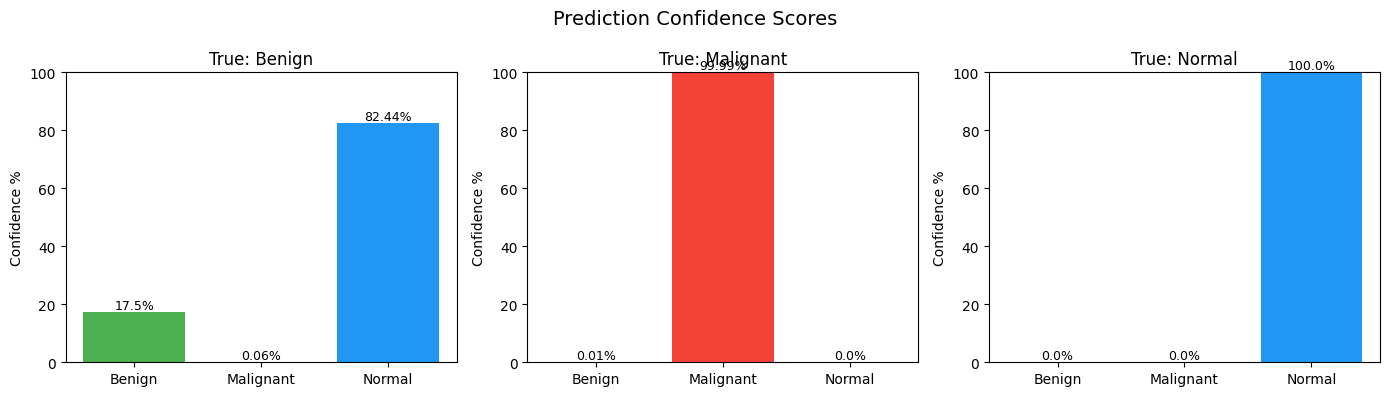

In [21]:
# Confidence bar chart

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Prediction Confidence Scores", fontsize=14)

for ax, (label, path) in zip(axes, images.items()):
    result = predict(path, model)
    scores = result['all_scores']

    bars = ax.bar(scores.keys(), scores.values(),
                  color=['#4CAF50', '#F44336', '#2196F3'])
    ax.set_title(f"True: {label}")
    ax.set_ylabel("Confidence %")
    ax.set_ylim(0, 100)

    for bar, val in zip(bars, scores.values()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f"{val}%", ha='center', fontsize=9)

plt.tight_layout()
plt.show()
